In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("C:/Users/AAGAM DOSHI/Downloads/Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [9]:
df.shape

(200, 5)

In [23]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

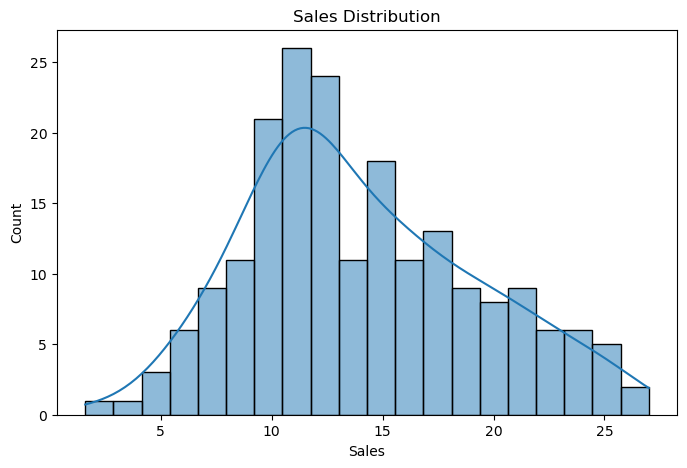

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Sales"],
    bins=20,
    kde=True
)

plt.title("Sales Distribution")

plt.show()

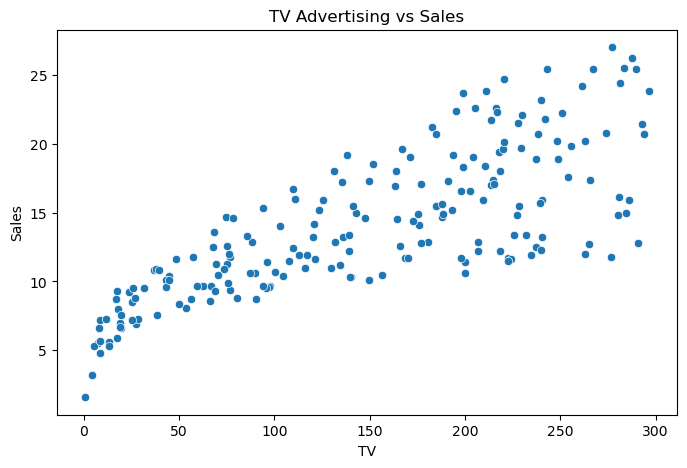

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="TV",
    y="Sales",
    data=df
)

plt.title("TV Advertising vs Sales")

plt.show()

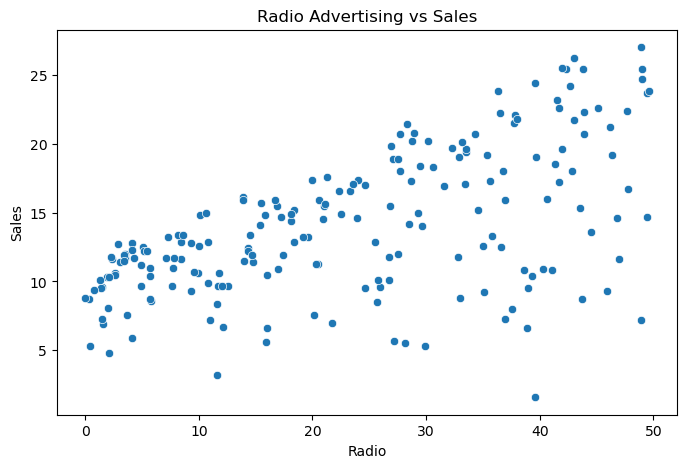

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Radio",
    y="Sales",
    data=df
)

plt.title("Radio Advertising vs Sales")

plt.show()

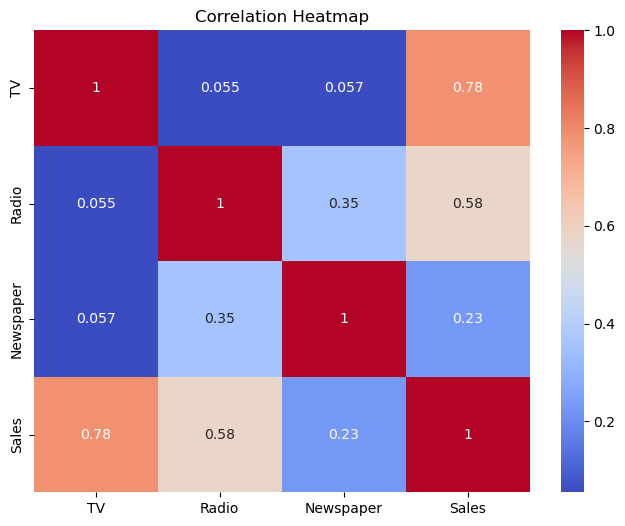

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

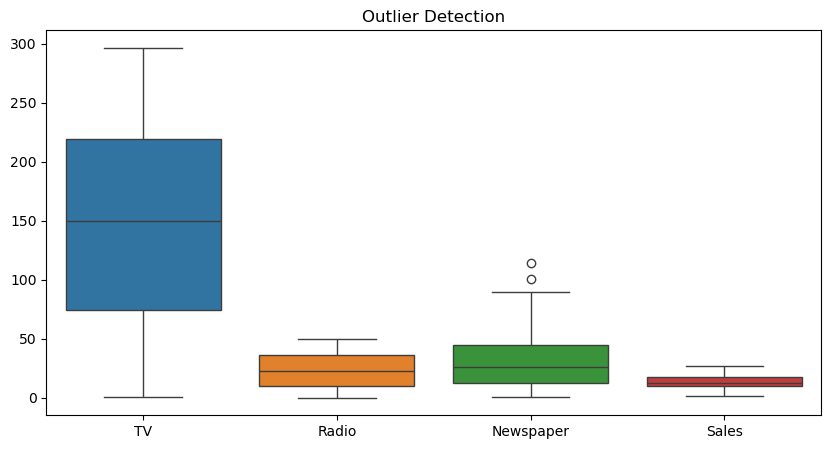

In [33]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df)

plt.title("Outlier Detection")

plt.show()

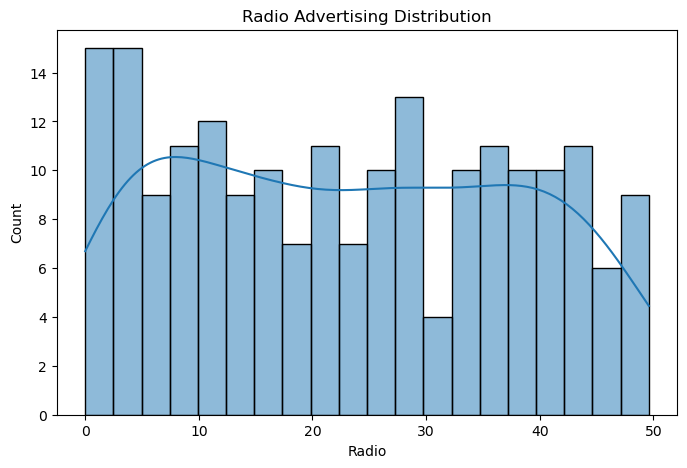

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Radio"],
    bins=20,
    kde=True
)

plt.title("Radio Advertising Distribution")

plt.show()

In [37]:
X = df[["TV", "Radio", "Newspaper"]]

y = df["Sales"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression Results")

print("MAE:",
      mean_absolute_error(y_test, pred_lr))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_lr)))

print("R2 Score:",
      r2_score(y_test, pred_lr))

Linear Regression Results
MAE: 1.4607567168117606
RMSE: 1.7815996615334502
R2 Score: 0.899438024100912


In [43]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Results")

print("MAE:",
      mean_absolute_error(y_test, pred_rf))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_rf)))

print("R2 Score:",
      r2_score(y_test, pred_rf))

Random Forest Results
MAE: 0.6200999999999988
RMSE: 0.7685910811348248
R2 Score: 0.9812843792541843


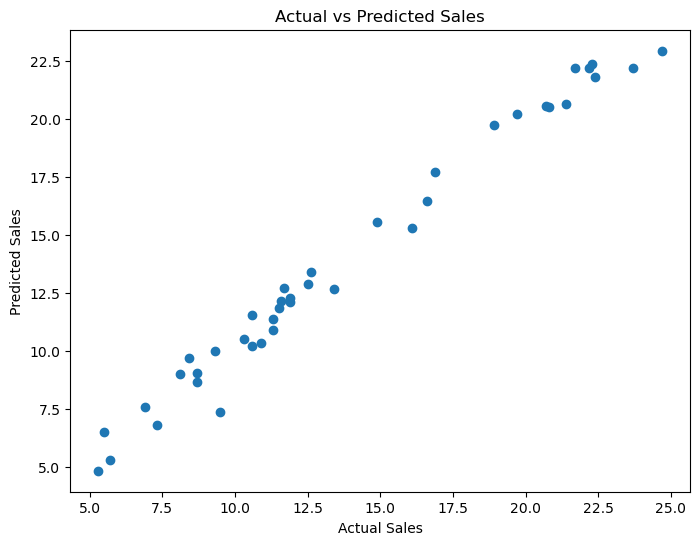

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred_rf
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()